In [21]:
import sys
sys.path.append('../')
from pprint import pprint

import itertools
import sympy as sp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from finite_groups import FiniteGroup
from induced_rep_solver import InducedRepSolver
from symchar.symchar import character_table

from groups.irrep_mats_generators import irreps_mats_Sn

def RELU(x): return sp.Max(0, x)
def TANH(x): return sp.tanh(x)
def SIGMOID(x): return 1 / (1 + sp.exp(-x))
def LINEAR(x): return x
def SQUARE(x): return x**2
def RELU_TANH(x): return RELU(x) + TANH(x)

# Utils

In [22]:
def build_Sn(n: int) -> FiniteGroup:
    if n < 1:
        raise ValueError("n must be >= 1")

    elements = list(itertools.permutations(range(n)))

    def mult(a, b):
        # composition a o b
        return tuple(a[i] for i in b)

    return FiniteGroup(elements, mult)



def build_H(n: int) -> list[tuple[int, ...]]:
    """Stabiliser of the last point n-1, isomorphic to S_{n-1}."""
    H = []
    for p in itertools.permutations(range(n - 1)):
        perm = list(range(n))
        for i in range(n - 1):
            perm[i] = p[i]
        perm[n - 1] = n - 1
        H.append(tuple(perm))
    return H

## Characters

In [23]:
def generate_partitions(n):
    def generate(n, max_part, current, result):
        if n == 0:
            result.append(tuple(current))
            return
        for i in range(min(max_part, n), 0, -1):
            generate(n - i, i, current + [i], result)

    result = []
    generate(n, n, [], result)
    return result

def cycle_type(perm: tuple[int, ...]) -> tuple[int, ...]:
    k = len(perm)
    seen = [False] * k
    parts = []

    for i in range(k):
        if seen[i]:
            continue
        j = i
        length = 0
        while not seen[j]:
            seen[j] = True
            j = perm[j]
            length += 1
        parts.append(length)

    return tuple(sorted(parts, reverse=True))

def Sn_character_table_map(G: FiniteGroup, n: int):
    """
    Character table for S_n using symchar.

    The symchar table is indexed by cycle type, so we convert the discovered
    conjugacy-class representatives into partitions.
    """
    from symchar.symchar import character_table

    raw = np.array(character_table(n), dtype=object).T
    partitions = generate_partitions(n)
    labels = [''.join(map(str, p)) for p in partitions]
    partition_map = {
        tuple(sorted(p, reverse=True)): i
        for i, p in enumerate(partitions)
    }

    class_char_map = {}
    for cls in G.classes:
        rep = cls.representative
        part = cycle_type(rep)
        if part not in partition_map:
            raise ValueError(f"Cycle type {part} not found in the partition map.")
        class_char_map[rep] = [sp.sympify(x) for x in raw[partition_map[part]]]

    return class_char_map, labels

def run(G,H,n, activation_fn, 
        refine=False, 
        regular=False, 
        irrep_mats=None, 
        interaction=False,
        figsize=(10,10)):

    solver = InducedRepSolver(G)
    if regular:
        solver.set_subgroup([G.identity])
    else:
        solver.set_subgroup(H)

    class_char_map, labels = Sn_character_table_map(G, n)

    solver.load_character_table(class_char_map, labels)

    if refine:
        irrep_mats = irreps_mats_Sn(n)
        solver.load_irrep_matrices(irrep_mats)

    solver.compute_projectors(refine=refine)

    if interaction:
        graph = solver.build_interaction_graph(activation_fn=activation_fn)
    else:
        graph = solver.build_isotypic_graph(activation_fn=activation_fn)

    solver.visualise_interaction_graph(
    graph,
    group_name=rf"$S_{n} \quad  (\text{{{activation_fn.__name__}}})$",
    node_size=2200,
    show_self_loops=False,
    figsize=figsize
)

    return graph, solver

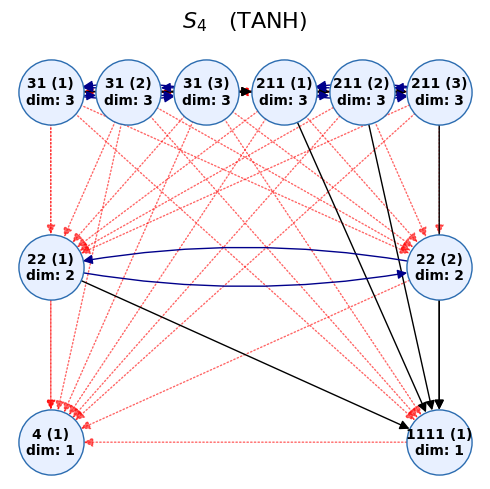

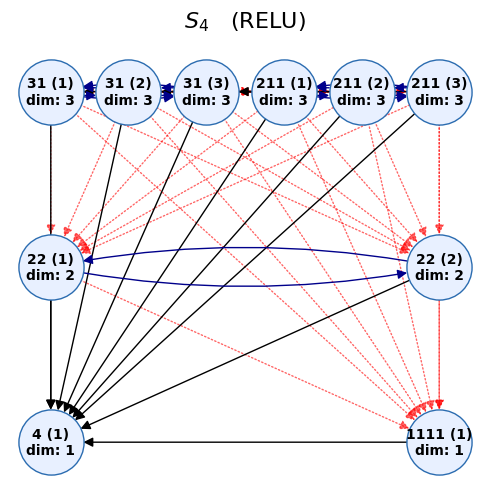

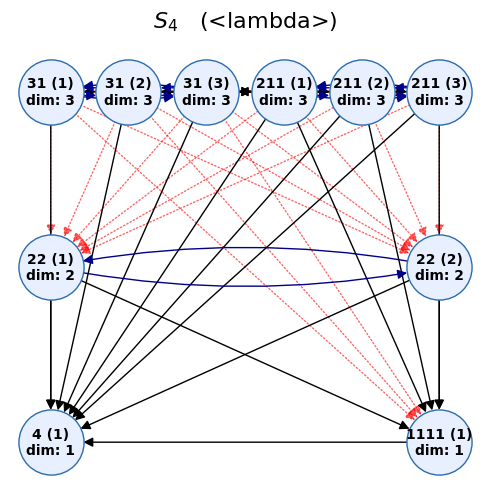

In [34]:
n = 4

activation_fn = TANH
regular = True
refine = True

G = build_Sn(n)
H = build_H(n)

graph, solver = run(G, H, n, TANH, refine=refine, regular=regular, figsize=(5,5), interaction=True)
graph, solver = run(G, H, n, RELU, refine=refine, regular=regular, figsize=(5,5), interaction=True)
graph, solver = run(G, H, n, lambda x: RELU(x) + TANH(x), refine=refine, regular=regular, figsize=(5,5), interaction=True)

In [30]:
col_ranges = {}
col_labels = []
copy_ranges = {}

start = 0
blocks = []

if refine:
    # copy_blocks keys look like: (label, k)
    items = list(solver.copy_blocks.items())

    for key, Qblock in items:
        r, c = Qblock.shape
        if r > 1 and c > 0:
            label, copy_idx = key
            pretty_label = f"{label} ({copy_idx + 1})"

            blocks.append(Qblock)

            end = start + c
            col_ranges[pretty_label] = (start, end)
            copy_ranges[key] = (start, end)
            col_labels.extend([pretty_label] * c)
            start = end
else:
    for label, Qblock in solver.Qblocks.items():
        r, c = Qblock.shape
        if r > 1 and c > 0:
            blocks.append(Qblock)

            end = start + c
            col_ranges[label] = (start, end)
            col_labels.extend([label] * c)
            start = end

if not blocks:
    raise ValueError("No nontrivial blocks found to build Q.")

Q = sp.Matrix(np.hstack([np.array(B.tolist(), dtype=object) for B in blocks]))
Q_inv = Q.inv()

pprint(col_ranges)
# sp.Matrix([0,1,0,0,0,0,0,0]).T * Q_inv * (Q * sp.Matrix([0,0,0,0,1,1,0,0])).applyfunc(activation_fn)
Q_inv * (Q).applyfunc(activation_fn)

{'1111 (1)': (23, 24),
 '211 (1)': (14, 17),
 '211 (2)': (17, 20),
 '211 (3)': (20, 23),
 '22 (1)': (10, 12),
 '22 (2)': (12, 14),
 '31 (1)': (1, 4),
 '31 (2)': (4, 7),
 '31 (3)': (7, 10),
 '4 (1)': (0, 1)}


Matrix([
[1,  3/4,  3/4,  3/4,  3/4,  3/4,  3/4,  3/4,  3/4,  3/4,  2/3,  2/3,  2/3,  2/3,  3/4,  3/4,  3/4,  3/4,  3/4,  3/4,  3/4,  3/4,  3/4, 1/2],
[0,  5/8, -1/8, -1/8, -1/8,  1/8,  1/8, -1/8,  1/8,  1/8,    0,    0,    0,    0, 1/24, 1/24, -1/8, 1/24, 1/24, -1/8, -1/8, -1/8,  3/8,   0],
[0, -1/8,  5/8, -1/8,  1/8, -1/8,  1/8,  1/8, -1/8,  1/8,    0,    0,    0,    0, 1/24, -1/8, 1/24, 1/24, -1/8, 1/24, -1/8,  3/8, -1/8,   0],
[0, -1/8, -1/8,  5/8,  1/8,  1/8, -1/8,  1/8,  1/8, -1/8,    0,    0,    0,    0, -1/8, 1/24, 1/24, -1/8, 1/24, 1/24,  3/8, -1/8, -1/8,   0],
[0, -1/8,  1/8,  1/8,  5/8, -1/8, -1/8, -1/8,  1/8,  1/8,    0,    0,    0,    0, 1/24, 1/24, -1/8, -1/8, -1/8,  3/8, 1/24, 1/24, -1/8,   0],
[0,  1/8, -1/8,  1/8, -1/8,  5/8, -1/8,  1/8, -1/8,  1/8,    0,    0,    0,    0, 1/24, -1/8, 1/24, -1/8,  3/8, -1/8, 1/24, -1/8, 1/24,   0],
[0,  1/8,  1/8, -1/8, -1/8, -1/8,  5/8,  1/8,  1/8, -1/8,    0,    0,    0,    0, -1/8, 1/24, 1/24,  3/8, -1/8, -1/8, -1/8, 1/24, 1/24,   0

In [29]:
col_ranges = {}
col_labels = []

start = 0
blocks = []

for label, Qblock in solver.Qblocks.items():
    r, c = Qblock.shape
    if r > 1:                      
        blocks.append(Qblock)

        end = start + c
        col_ranges[label] = (start, end)
        col_labels.extend([label] * c)
        start = end


Q = sp.Matrix(np.hstack(blocks))
Q_inv = Q.inv()


pprint(col_ranges)
# sp.Matrix([0,1,0,0,0,0,0,0]).T * Q_inv * (Q * sp.Matrix([0,0,0,0,1,1,0,0])).applyfunc(activation_fn)
Q_inv * (Q).applyfunc(activation_fn)

{'1111': (23, 24), '211': (14, 23), '22': (10, 14), '31': (1, 10), '4': (0, 1)}


Matrix([
[1,  9/8, 9/8, 9/8,  9/8,  9/8, 9/8,  9/8,  9/8,  9/8, 2/3,  2/3,  2/3, 2/3,  9/8, 9/8, 9/8,  9/8,  9/8, 9/8,  9/8,  9/8,  9/8, 1/2],
[0,  5/8,   0,   0,    0,    0,   0,    0,    0,    0,   0,    0,    0,   0,  1/8,   0,   0,    0,    0,   0,    0,    0,    0,   0],
[0,    0, 5/8,   0,    0,    0,   0,    0,    0,    0,   0,    0,    0,   0,    0, 1/8,   0,    0,    0,   0,    0,    0,    0,   0],
[0,    0,   0, 5/8,    0,    0,   0,    0,    0,    0,   0,    0,    0,   0,    0,   0, 1/8,    0,    0,   0,    0,    0,    0,   0],
[0,    0,   0,   0,  5/8,    0,   0,    0,    0,    0,   0,    0,    0,   0,    0,   0,   0,  1/8,    0,   0,    0,    0,    0,   0],
[0,    0,   0,   0,    0,  5/8,   0,    0,    0,    0,   0,    0,    0,   0,    0,   0,   0,    0,  1/8,   0,    0,    0,    0,   0],
[0,    0,   0,   0,    0,    0, 5/8,    0,    0,    0,   0,    0,    0,   0,    0,   0,   0,    0,    0, 1/8,    0,    0,    0,   0],
[0,    0,   0,   0,    0,    0,   0,  5/8,    0,    0

In [ ]:
def run(n,k, activation=RELU, Cn_labels=None):

    G = build_Sn(n)
    H = build_H(n)

    solver = InducedRepSolver(G)
    solver.set_subgroup(H)

    class_char_map, labels = Sn_character_table_map(G, n)

    solver.load_character_table(class_char_map, labels)
    solver.compute_projectors(refine=False)

    # graph = solver.build_interaction_graph(activation_fn=activation_fn)
    graph = solver.build_isotypic_graph(activation_fn=activation_fn)

    return graph, solver

In [43]:
graphs = {}
n = 4
activation_fn = RELU

for i in range(1, n+1):
    for j in range(1, n+1):
        print(f"Computing C{i+1} x S{j+1}")
        graphs[(i, j)] = run(i, j, activation=activation_fn)

def create_svg_grid(graphs, n, filename="grid.svg"):

    fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            graph, solver = graphs[(i+1, j+1)]
            solver.visualise_interaction_grid(graph, ax=ax, group_name=f"C{i+1} x S{j+1}")


    plt.tight_layout()
    fig.savefig(filename, format="svg")
    plt.close(fig)


create_svg_grid(graphs, n=n, filename=f"outputs/Regular_Cn_Sk_n={n}_{activation_fn.__name__}.svg")

Computing C2 x S2
Computing C2 x S3
Computing C2 x S4
Computing C2 x S5
Computing C3 x S2
Computing C3 x S3
Computing C3 x S4
Computing C3 x S5
Computing C4 x S2
Computing C4 x S3
Computing C4 x S4
Computing C4 x S5
Computing C5 x S2
Computing C5 x S3
Computing C5 x S4
Computing C5 x S5
